In [1]:

######## snakemake preamble start (automatically inserted, do not edit) ########
library(methods)
Snakemake <- setClass(
    "Snakemake",
    slots = c(
        input = "list",
        output = "list",
        params = "list",
        wildcards = "list",
        threads = "numeric",
        log = "list",
        resources = "list",
        config = "list",
        rule = "character",
        bench_iteration = "numeric",
        scriptdir = "character",
        source = "function"
    )
)
snakemake <- Snakemake(
    input = list('results/mtbc1175_2/benchmarking/detettore/benchmark_summary.tsv'),
    output = list('results/mtbc1175_2/plots/recall_precision.svg'),
    params = list(),
    wildcards = list(),
    threads = 1,
    log = list('logs/benchmarking.ipynb', "notebook" = 'logs/benchmarking.ipynb'),
    resources = list('mem_mb', 'mem_mib', 'disk_mb', 'disk_mib', 'tmpdir', 'runtime', 'qos', 'cpus_per_task', 'slurm_account', "mem_mb" = 4000, "mem_mib" = 3815, "disk_mb" = 1000, "disk_mib" = 954, "tmpdir" = '/scratch/stritt0001/slurm-job.36254830', "runtime" = 360, "qos" = '6hours', "cpus_per_task" = 1, "slurm_account" = 'gagneux'),
    config = list("input" = list("gnumbers" = '/scicore/home/gagneux/stritt0001/TB/projects/MTBC_IS6110-poly/data/mtbc1175/gnumbers.txt', "reference" = '../data/MTBC0_v1.1.fasta', "assemblies" = 'config/datasets/30assemblies.tsv', "path_to_db" = '/scicore/home/gagneux/GROUP/tbresearch/genomes/IN_PROGRESS/common_mappings/PipelineTB/v2'), "outdir" = 'results/mtbc1175_2', "detettore" = list("is_target" = 'software/detettore6110/resources/is_targets/IS6110.fasta', "is_cluster" = 'IS3_168'), "phylogeny" = list("outgroup" = 'G742339'), "benchmarking" = list("min_id" = 0.9, "anchor_length" = 300, "readlengths" = c(100, 150), "coverages" = c(20, 30, 40, 50), "hit_lengths" = c(20, 40), "min_cluster_size" = c(3, 5))),
    rule = 'summarize',
    bench_iteration = as.numeric(NA),
    scriptdir = '/scicore/home/gagneux/stritt0001/TB/projects/MTBC_IS6110-poly/workflow/rules/../notebooks',
    source = function(...){
        wd <- getwd()
        setwd(snakemake@scriptdir)
        source(...)
        setwd(wd)
    }
)
setwd('/scicore/home/gagneux/stritt0001/TB/projects/MTBC_IS6110-poly/workflow');

######## snakemake preamble end #########


# Benchmarking stats and figures

- plot recall (sensitivity) and precision
- glm to identify what affects recall and precision
- implement in Snakemake workflow

In [2]:
t <- read.table(snakemake@input[[1]], sep='\t', header=T)
#t <- read.table(
#    '/scicore/home/gagneux/stritt0001/TB/projects/MTBC_IS6110-poly/workflow/results/mtbc1175_2/benchmarking/detettore/benchmark_summary.tsv',
#    sep='\t', header=T)

t$assembly <- as.factor(t$assembly)
t$side <- as.factor(t$side)
t$coverage <- as.factor(t$coverage)
t$readlength <- as.factor(t$readlength)
t$hitlength <- as.factor(t$hitlength)
t$minclustersize <- as.factor(t$minclustersize)

# Add recall, precision, F1
t$recall = t$true_positives / (t$true_positives + t$false_negatives)
t$precision = t$true_positives / (t$true_positives + t$false_positives)
t$f1 = 2 * (t$precision * t$recall) / (t$precision + t$recall)
head(t)
summary(t)

,assembly,coverage,readlength,hitlength,minclustersize,copy_number,side,true_positives,false_negatives,false_positives,recall,precision,f1
,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,ASM2155989v1,20,100,20,3,18,5,16,2,0,0.8888889,1,0.9411765
2,ASM2155989v1,20,100,20,3,18,3,15,3,0,0.8333333,1,0.9090909
3,ASM2155989v1,20,100,20,5,18,5,12,6,0,0.6666667,1,0.8000000
4,ASM2155989v1,20,100,20,5,18,3,9,9,0,0.5000000,1,0.6666667
5,ASM2155989v1,20,100,40,3,18,5,12,6,0,0.6666667,1,0.8000000
6,ASM2155989v1,20,100,40,3,18,3,12,6,0,0.6666667,1,0.8000000


         assembly    coverage readlength hitlength minclustersize
 ASM1292376v1:  64   20:480   100:960    20:960    3:960         
 ASM1526549v2:  64   30:480   150:960    40:960    5:960         
 ASM15368v2  :  64   40:480                                      
 ASM154505v1 :  64   50:480                                      
 ASM1614v1   :  64                                               
 ASM1692v1   :  64                                               
 (Other)     :1536                                               
  copy_number   side    true_positives  false_negatives  false_positives 
 Min.   : 0.0   3:960   Min.   : 0.00   Min.   : 0.000   Min.   :0.0000  
 1st Qu.: 3.0   5:960   1st Qu.: 2.00   1st Qu.: 0.000   1st Qu.:0.0000  
 Median :14.5           Median :11.00   Median : 0.000   Median :0.0000  
 Mean   :11.5           Mean   :10.43   Mean   : 1.073   Mean   :0.4984  
 3rd Qu.:17.0           3rd Qu.:17.00   3rd Qu.: 1.000   3rd Qu.:0.0000  
 Max.   :25.0           Max.

## Recall

In [3]:
aggregate(recall~coverage+readlength+hitlength+minclustersize, t, mean)

coverage,readlength,hitlength,minclustersize,recall
<fct>,<fct>,<fct>,<fct>,<dbl>
20,100,20,3,0.8979426
30,100,20,3,0.9871791
40,100,20,3,0.9914080
50,100,20,3,0.9770115
20,150,20,3,0.9902540
30,150,20,3,0.9942529
40,150,20,3,0.9942529
50,150,20,3,0.9928736
20,100,40,3,0.6278153


In [4]:
m_recall <- glm(recall~assembly+coverage+readlength+hitlength+minclustersize, data=t, family=binomial, weights = t$copy_number)
summary(m_recall)


Call:
glm(formula = recall ~ assembly + coverage + readlength + hitlength + 
    minclustersize, family = binomial, data = t, weights = t$copy_number)

Coefficients:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)            2.2920354  0.1384377  16.556  < 2e-16 ***
assemblyASM1526549v2  -0.0504209  0.1634945  -0.308  0.75778    
assemblyASM15368v2     0.0728674  0.2224121   0.328  0.74320    
assemblyASM154505v1   -0.1210585  0.1780997  -0.680  0.49668    
assemblyASM1614v1     -0.1042791  0.1784463  -0.584  0.55897    
assemblyASM1692v1     -0.0008822  0.1806657  -0.005  0.99610    
assemblyASM19583v2     0.4494738  0.6224603   0.722  0.47024    
assemblyASM19595v2    -0.1869703  0.1796225  -1.041  0.29792    
assemblyASM2155989v1  -0.1869703  0.1742025  -1.073  0.28314    
assemblyASM22443v1    -0.5770052  0.1753482  -3.291  0.00100 ***
assemblyASM25335v1    -0.1471787  0.2348206  -0.627  0.53081    
assemblyASM25337v1    -1.9628308  0.2585058  -7.593 3

## Precision

In [5]:
aggregate(precision~coverage+readlength+hitlength+minclustersize, t, mean)

coverage,readlength,hitlength,minclustersize,precision
<fct>,<fct>,<fct>,<fct>,<dbl>
20,100,20,3,0.9392793
30,100,20,3,0.9381260
40,100,20,3,0.9381735
50,100,20,3,0.9371256
20,150,20,3,0.9381735
30,150,20,3,0.9381735
40,150,20,3,0.9381735
50,150,20,3,0.9374850
20,100,40,3,0.9254332


In [6]:
m_precision <- glm(precision~assembly+coverage+readlength+hitlength+minclustersize, data=t, family=binomial, weights = t$copy_number)
summary(m_precision)

Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”



Call:
glm(formula = precision ~ assembly + coverage + readlength + 
    hitlength + minclustersize, family = binomial, data = t, 
    weights = t$copy_number)

Coefficients: (1 not defined because of singularities)
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)              2.76164    0.16742  16.495  < 2e-16 ***
assemblyASM1526549v2     0.33400    0.18198   1.835   0.0665 .  
assemblyASM15368v2      21.11898 4163.66831   0.005   0.9960    
assemblyASM154505v1     21.69304 4036.70748   0.005   0.9957    
assemblyASM1614v1        0.63098    0.22210   2.841   0.0045 ** 
assemblyASM1692v1       21.69304 4036.70748   0.005   0.9957    
assemblyASM19583v2      19.65862 6218.71975   0.003   0.9975    
assemblyASM19595v2      21.63687 4045.72023   0.005   0.9957    
assemblyASM2155989v1    21.74622 4028.68467   0.005   0.9957    
assemblyASM22443v1      21.57737 4055.91970   0.005   0.9958    
assemblyASM25335v1      20.90377 4239.50362   0.005   0.9961    
asse

## Figures

In [7]:
library(cowplot)
library(ggplot2)
library(magrittr)
library(plotly)

options(repr.plot.width = 15, repr.plot.height = 12, warn=-1)

# Plot recall
recall_figures <- list()
for (l in c(100,150)){
    recall_figures[[as.character(l)]] <- subset(t, readlength==l & side == 5) %>% ggplot(aes(y=recall, x=coverage, group=assembly)) + facet_grid(hitlength~minclustersize) +
        geom_point(alpha=0.5) + geom_line(alpha=0.5) + theme_minimal()
}

# Plot precision
precision_figures <- list()
for (l in c(100,150)){
    precision_figures[[as.character(l)]] <- subset(t, readlength==l & side == 5) %>% ggplot(aes(y=precision, x=coverage, group=assembly)) + facet_grid(hitlength~minclustersize) +
        geom_point(alpha=0.5) + geom_line(alpha=0.5) + theme_minimal()
}


Attaching package: ‘plotly’




The following object is masked from ‘package:ggplot2’:

    last_plot




The following object is masked from ‘package:stats’:

    filter




The following object is masked from ‘package:graphics’:

    layout




Combine plots

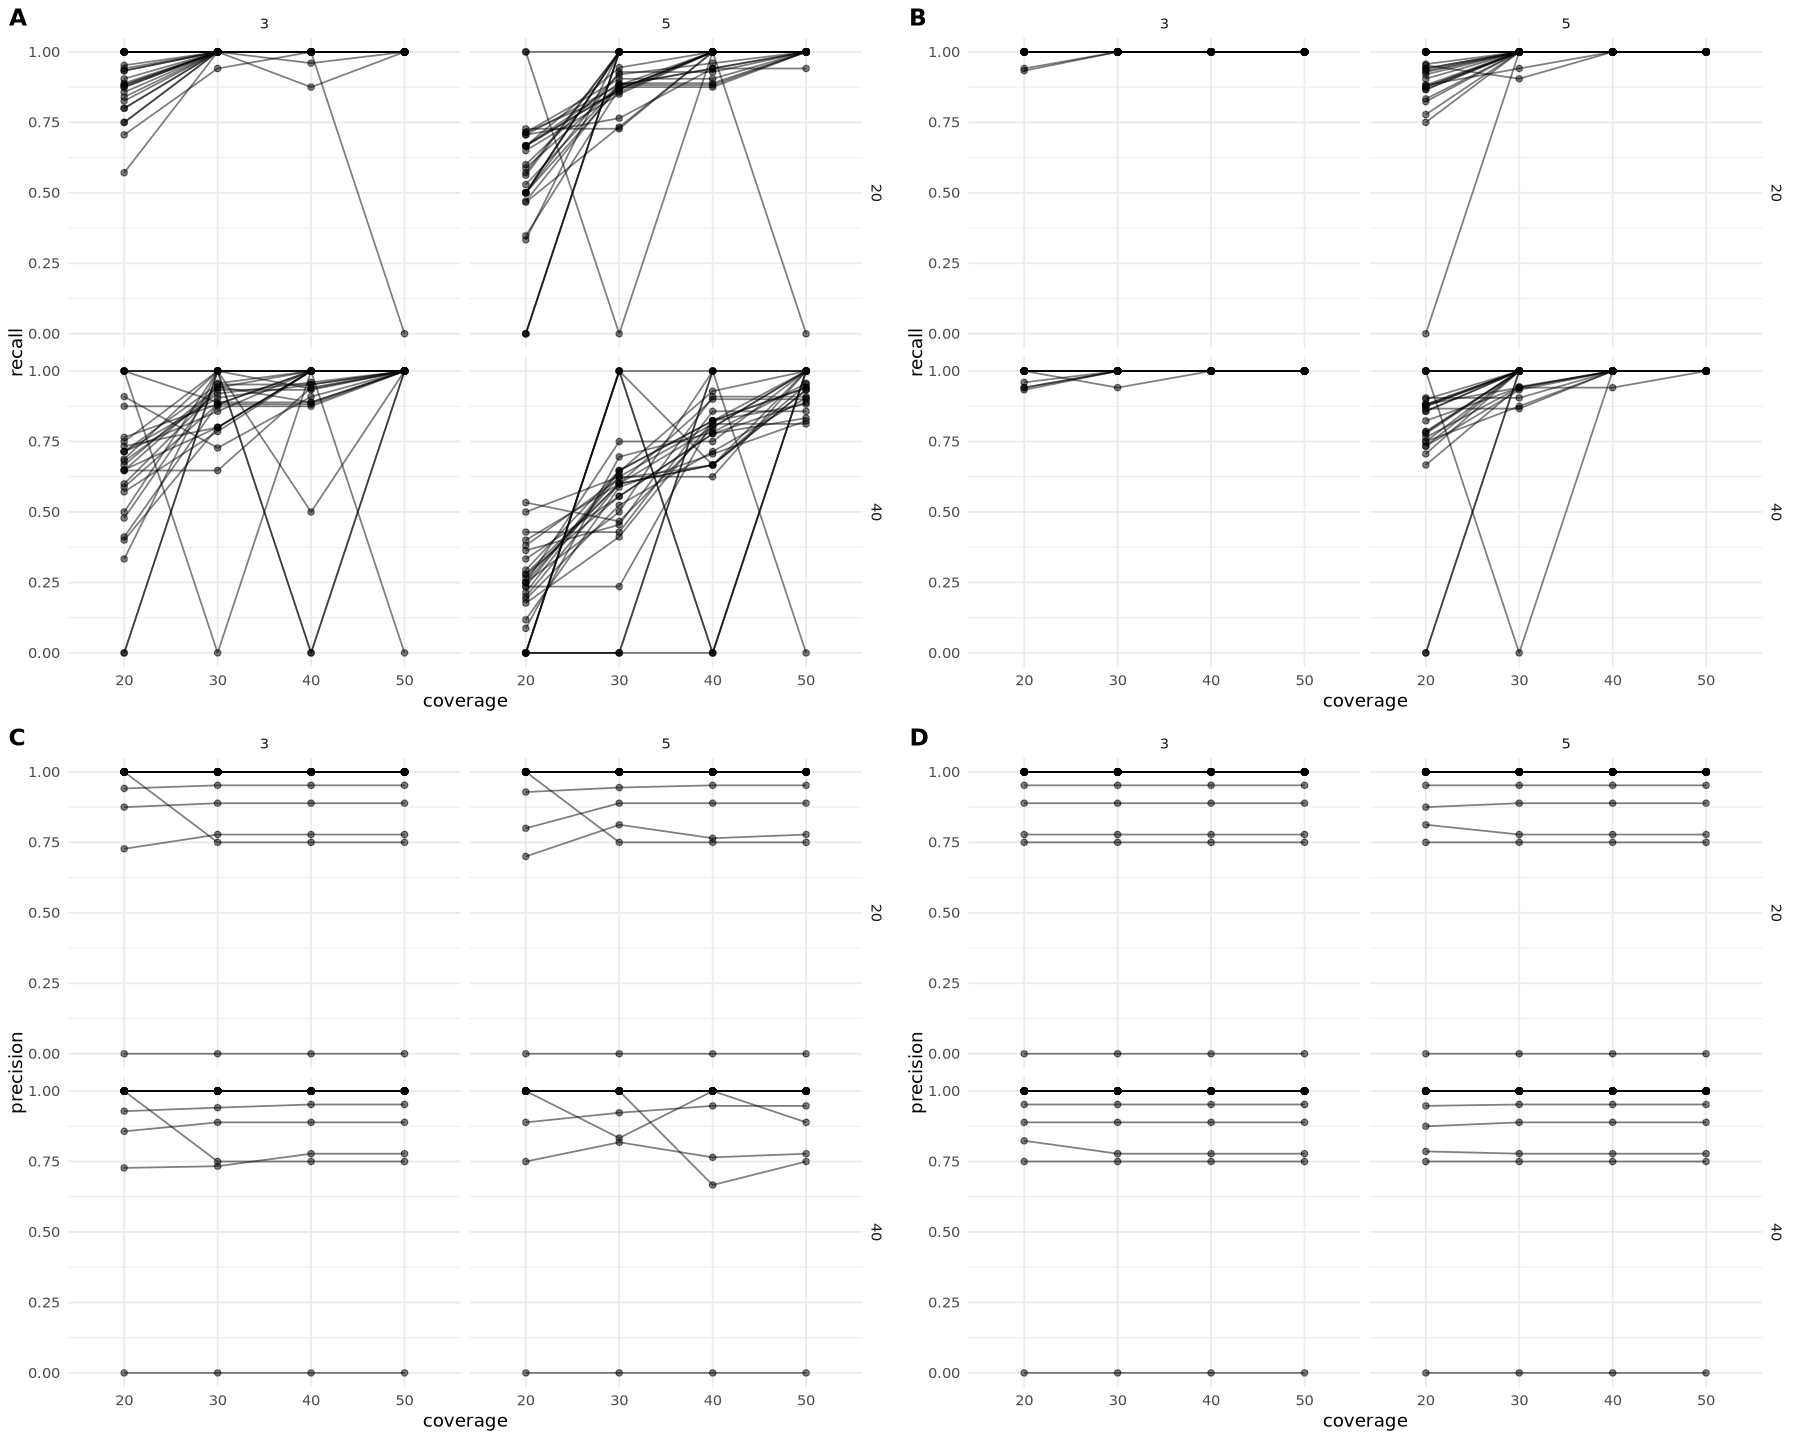

In [8]:
recall_panel <- plot_grid(
    recall_figures[[as.character(100)]], recall_figures[[as.character(150)]],
    labels = c('A', 'B'), nrow=1)

precision_panel <- plot_grid(
    precision_figures[[as.character(100)]], precision_figures[[as.character(150)]],
    labels = c('C','D'), nrow=1)

figs1 <- plot_grid(recall_panel, precision_panel, nrow = 2)
figs1

Same but for detettore6110 default values hit_length = 20 and min_cluster_size = 3, which work best.

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8, warn=-1)

t_default = subset(t, hitlength == 20 & minclustersize == 3)

a <- t_default %>% 
    ggplot(aes(y=recall, x=coverage, col=side,group=interaction(assembly,side))) + 
    geom_point(alpha=0.5) + geom_line(alpha=0.5) + 
    facet_wrap(~readlength) + 
    theme(text = element_text(size = 12)) +
    theme_bw() + ylab('Recall') + xlab(NULL)

b <- t_default %>% 
    ggplot(aes(y=precision, x=coverage, col=side,group=interaction(assembly,side))) + 
    geom_point(alpha=0.5) + geom_line(alpha=0.5) + 
    facet_wrap(~readlength) + 
    theme(text = element_text(size = 12)) +
    theme_bw() + ylab('Precision') + xlab('Coverage')

comb_default <- plot_grid(a,b, ncol=1, labels = c('A', 'B'))
comb_default
ggsave(snakemake@output[[1]], comb_default, width=10, height=8)